In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

In [2]:
import pandas as pd

data = pd.DataFrame({
    "hours_studied": [1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9, 10],
    "attendance":    [55, 60, 65, 62, 70, 68, 75, 72, 80, 78, 85, 82, 90, 88, 95, 92, 96],
    "admitted":      [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
})

print(data)

    hours_studied  attendance  admitted
0               1          55         0
1               2          60         0
2               2          65         0
3               3          62         0
4               3          70         0
5               4          68         0
6               4          75         1
7               5          72         1
8               5          80         1
9               6          78         1
10              6          85         1
11              7          82         1
12              7          90         1
13              8          88         1
14              8          95         1
15              9          92         1
16             10          96         1


In [3]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [4]:
def compute_fwb(X, w, b):
    return sigmoid(np.dot(X,w) + b)

In [5]:
def compute_cost(X, y, w, b, fwb_function=compute_fwb):
     m = X.shape[0]
     cost = 0
     for i in range(m):
          fwb_i = fwb_function(X[i], w, b)
          cost += -y[i]*(np.log(fwb_i)) - (1 - y[i])*(np.log(1-fwb_i))

     return cost/m

In [6]:
def compute_gradient(X, y, w, b, fwb_function=compute_fwb):
    djdw = 0
    djdb = 0
    m = X.shape[0]

    for i in range(m):
        fwb_i = fwb_function(X[i], w, b)

        djdw += (fwb_i - y[i]) * X[i]
        djdb += (fwb_i - y[i])

    return djdw/m, djdb/m

In [7]:
def gradient_descent(X, y, w_inp, b_inp, alpha, num_iter=10000, cost_function = compute_cost, gradient_function=compute_gradient, tolerance=1e-7):
    w = w_inp
    b = b_inp
    m, n = X.shape

    j_history = []
    p_history = []

    for i in range(num_iter):
        djdw, djwb = gradient_function(X, y, w, b)

        w = w-alpha*djdw
        b = b-alpha*djwb

        cost = cost_function(X, y, w, b)
        j_history.append(cost)
        p_history.append([w, b])

        if i % math.ceil(num_iter/10) == 0:
            print(f"Iteration {i:4d}: Cost {float(cost):8.4f}")

        if i > 2 and abs(cost - j_history[-2]) < tolerance:
            break

    return w, b, p_history, j_history

In [8]:
X = data[["hours_studied", "attendance"]].values
y = data["admitted"].values

In [9]:
X

array([[ 1, 55],
       [ 2, 60],
       [ 2, 65],
       [ 3, 62],
       [ 3, 70],
       [ 4, 68],
       [ 4, 75],
       [ 5, 72],
       [ 5, 80],
       [ 6, 78],
       [ 6, 85],
       [ 7, 82],
       [ 7, 90],
       [ 8, 88],
       [ 8, 95],
       [ 9, 92],
       [10, 96]])

In [10]:
y

array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [11]:
not_admitted = y == 0
admitted = y == 1

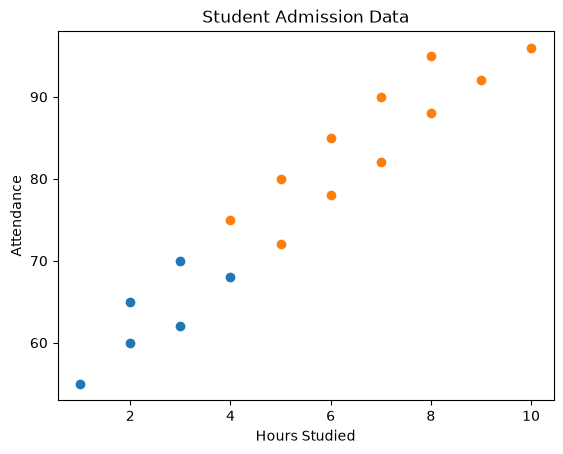

In [12]:
plt.scatter(X[not_admitted, 0], X[not_admitted, 1])
plt.scatter(X[admitted, 0], X[admitted, 1])

plt.xlabel("Hours Studied")
plt.ylabel("Attendance")
plt.title("Student Admission Data")

plt.show()

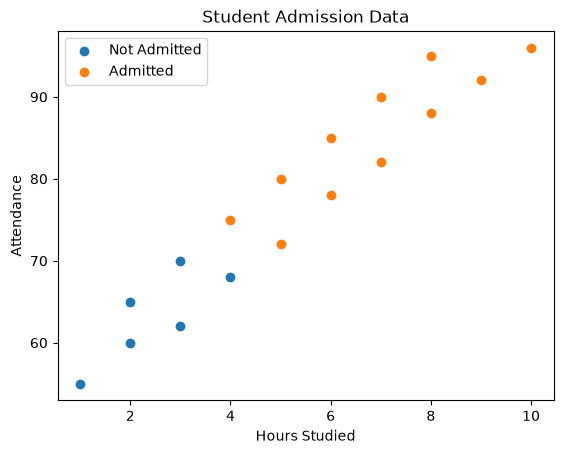

In [13]:
plt.scatter(X[not_admitted, 0], X[not_admitted, 1], label="Not Admitted")
plt.scatter(X[admitted, 0], X[admitted, 1], label="Admitted")

plt.xlabel("Hours Studied")
plt.ylabel("Attendance")
plt.title("Student Admission Data")

plt.legend()
plt.show()

In [14]:
w_init = np.zeros(X.shape[1])
b_init = 0

w, b, p_history, j_history = gradient_descent(
    X,
    y,
    w_init,
    b_init,
    alpha=0.001,
    num_iter=10000,
    tolerance=1e-7
)

print(w)
print(b)

Iteration    0: Cost   0.6173
Iteration 1000: Cost   0.3907
Iteration 2000: Cost   0.3113
Iteration 3000: Cost   0.2710
Iteration 4000: Cost   0.2467
Iteration 5000: Cost   0.2303
Iteration 6000: Cost   0.2185
Iteration 7000: Cost   0.2095
Iteration 8000: Cost   0.2025
Iteration 9000: Cost   0.1968
[ 1.63297576 -0.08632362]
-0.21152608080556778


In [15]:
print(len(j_history))
print(j_history[:5])
print(j_history[-5:])

10000
[np.float64(0.6172620237459652), np.float64(0.602780874770217), np.float64(0.6021610409539614), np.float64(0.6017804088568802), np.float64(0.6014166669928254)]
[np.float64(0.19216446488336206), np.float64(0.1921601903175889), np.float64(0.19215591649722275), np.float64(0.1921516434220661), np.float64(0.19214737109192148)]


In [16]:
print(j_history)
print(abs(j_history[-1] - j_history[-2]))
print(1e-7)

[np.float64(0.6172620237459652), np.float64(0.602780874770217), np.float64(0.6021610409539614), np.float64(0.6017804088568802), np.float64(0.6014166669928254), np.float64(0.6010543526936223), np.float64(0.6006925580128757), np.float64(0.6003312267281726), np.float64(0.5999703548729256), np.float64(0.5996099416402165), np.float64(0.5992499864162181), np.float64(0.5988904885988199), np.float64(0.5985314475870043), np.float64(0.5981728627801168), np.float64(0.5978147335778479), np.float64(0.5974570593802274), np.float64(0.5970998395876277), np.float64(0.5967430736007668), np.float64(0.5963867608207097), np.float64(0.5960309006488714), np.float64(0.595675492487019), np.float64(0.5953205357372733), np.float64(0.5949660298021118), np.float64(0.5946119740843716), np.float64(0.5942583679872492), np.float64(0.5939052109143059), np.float64(0.5935525022694685), np.float64(0.5932002414570297), np.float64(0.592848427881654), np.float64(0.5924970609483772), np.float64(0.5921461400626091), np.float64

In [17]:
print(gradient_descent.__defaults__)

(10000, <function compute_cost at 0x00000284CA64A610>, <function compute_gradient at 0x00000284CA64BC10>, 1e-07)


In [18]:
import inspect

print(inspect.getsource(gradient_descent))

def gradient_descent(X, y, w_inp, b_inp, alpha, num_iter=10000, cost_function = compute_cost, gradient_function=compute_gradient, tolerance=1e-7):
    w = w_inp
    b = b_inp
    m, n = X.shape

    j_history = []
    p_history = []

    for i in range(num_iter):
        djdw, djwb = gradient_function(X, y, w, b)

        w = w-alpha*djdw
        b = b-alpha*djwb

        cost = cost_function(X, y, w, b)
        j_history.append(cost)
        p_history.append([w, b])

        if i % math.ceil(num_iter/10) == 0:
            print(f"Iteration {i:4d}: Cost {float(cost):8.4f}")

        if i > 2 and abs(cost - j_history[-2]) < tolerance:
            break

    return w, b, p_history, j_history



In [19]:
z = np.dot(X, w) + b
predictions = sigmoid(z)

print(predictions)

[0.03467822 0.10669136 0.07198367 0.33969282 0.205013   0.61072735
 0.46160207 0.85043945 0.74028741 0.94547798 0.90454875 0.98433854
 0.96923645 0.99480991 0.99054335 0.9985626  0.99960299]


In [20]:
student_index = np.arange(len(y))

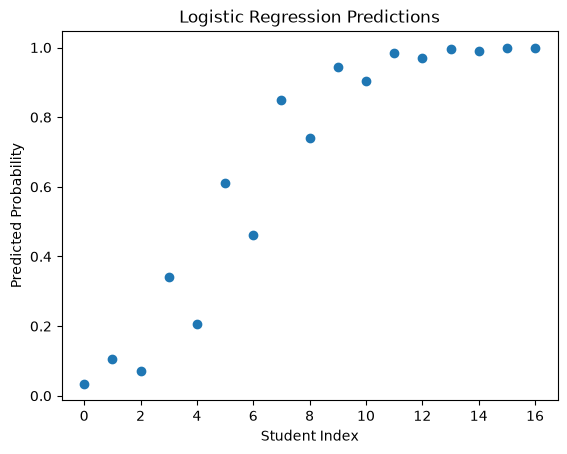

In [21]:
plt.scatter(student_index, predictions)
plt.xlabel("Student Index")
plt.ylabel("Predicted Probability")
plt.title("Logistic Regression Predictions")
plt.show()

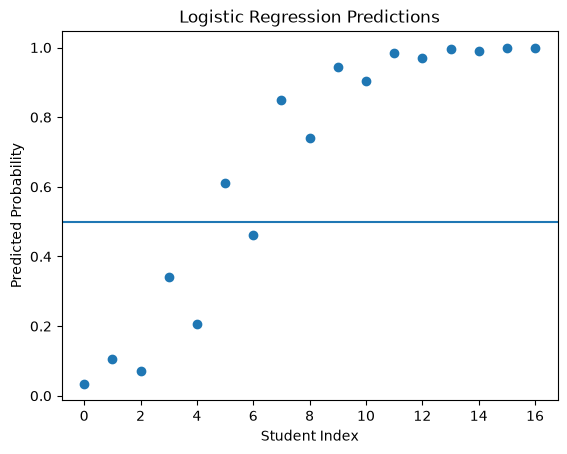

In [22]:
plt.scatter(student_index, predictions)

plt.axhline(0.5)

plt.xlabel("Student Index")
plt.ylabel("Predicted Probability")
plt.title("Logistic Regression Predictions")

plt.show()

In [23]:
def predict(X, w, b, threshold=0.5):
    """
    Predict whether the label is 0 or 1 using learned logistic regression parameters w, b
    """
    # Calculate predictions (probabilities)
    z = np.dot(X, w) + b
    p = sigmoid(z)
    
    # Apply threshold
    y_pred = (p >= threshold).astype(int)
    return y_pred

In [24]:
y_pred = predict(X, w, b)
print("Predictions:", y_pred)
print("Actual:     ", y)
print(f"Accuracy: {np.mean(y_pred == y) * 100:.2f}%")

Predictions: [0 0 0 0 0 1 0 1 1 1 1 1 1 1 1 1 1]
Actual:      [0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1]
Accuracy: 88.24%
